# ftir_26 — does IMPROVE HIPS itself read a nonzero Fabs at EC = 0?

## tl;dr

**IMPROVE HIPS does not have a 21.5 Mm⁻¹ zero — but killing that explanation does not close
the Addis intercept, and the notebook says so.** On 160,023 IMPROVE filters carrying both HIPS
Fabs and quartz TOR EC (the ftir_16 join, reproduced to the digit: implied MAC median **11.96**,
Addis-like subset **10.05**), the Fabs-at-EC-0 intercept is **+1.345 Mm⁻¹** [+1.19, +1.48]
pooled, **+0.200** trimmed at EC ≤ p95, **+2.163 → +0.097** on the Addis-like OC/EC ≤ 2.27
cohort, and **+0.251** as a per-site median — every one of them **≤ 1 %** of the Addis
C = 21.5 Mm⁻¹. A λ sweep shows the pooled intercept is **monotone increasing in λ**
(+0.538 → +1.345), so the OLS column is the **maximum over all errors-in-variables weightings**
and a hard upper bound. The assumption-free version needs no fit at all: on the **4,247** filters
with TOR EC ≤ 0, median Fabs is **+0.12 Mm⁻¹** and **23.8 %** read *negative* Fabs — a zero that
scatters through zero. And the offset is arithmetically impossible at that size anyway: only
**186 of 160,023** IMPROVE filters (**0.12 %**) carry 21.5 Mm⁻¹ of *total* absorption.
**The unplanned finding is geometric.** Fabs = k·EC^p fits pooled at **k = 7.50, p = 0.796,
R² = 0.713** and passes through zero with no offset term; feeding that curve — true offset
exactly 0, no noise — to a straight-line fit manufactures **+0.87 Mm⁻¹** of intercept, 64 % of
the observed pooled value. Per-site intercepts run at a median **35 %** of site mean Fabs
(IQR 27–50 %); the Addis figure is 21.5/47.11 = **46 %**, and **29 %** of IMPROVE sites
(29–34 % across inclusion variants) equal or exceed it in data whose true offset at zero is ~0.
**The one thing that survives**: per-site intercepts scale with loading (r = **0.689**, slope
**0.338** per Mm⁻¹ of site median Fabs), and extrapolating to Addis's 47.11 gives **16.2 Mm⁻¹
≈ 75 % of C** — but IMPROVE's dirtiest site median is **8.1 Mm⁻¹**, so that is **5.8× beyond
support** and cannot be treated as a result. The loading-*independent* part of that regression
is only **+0.221 Mm⁻¹** [+0.08, +0.37], which is what actually rules out an additive HIPS zero.

## Context & Methods

The Addis Fabs–EC crossplot carries an intercept of **C = 21.5 Mm⁻¹** (2.15 µg/m³ at the
network MAC = 10) against an Addis site median Fabs of **47.11 Mm⁻¹** — i.e. HIPS reads
roughly half the Addis absorption with no EC to go with it. One explanation on the table is
the simplest one: **HIPS has a nonzero zero.** If the transmissometer reports absorption on
a filter that carries no light-absorbing carbon, every Fabs–EC fit inherits that offset and
the Addis intercept is an instrument property rather than an aerosol property.

IMPROVE is the place to test that, because IMPROVE filters carry **both** measurements on
the same network: HIPS Fabs on Teflon and thermal-optical (TOR) EC on the co-located quartz
channel. If HIPS had a generic additive zero of order 20 Mm⁻¹, IMPROVE filters with TOR
EC ≈ 0 would have to read it too.

### Columns and units (stated explicitly — the two tables do not share a unit convention)

| Axis | Table | Filter | Column | Unit |
|---|---|---|---|---|
| y | `FTIR/local_db/tables/results_hips.csv` | `Parameter == 'fAbs'` | `Value` | **Mm⁻¹** |
| x | `FTIR/local_db/tables/results_tor.csv` | `Parameter == 'EC'` | `Value` | **ng/m³** → ÷1000 for µg/m³ |
| ratio | same TOR table | `Parameter == 'OC'` | `Value` | ng/m³ (cancels in OC/EC) |

The join is `ftir_16`'s, verbatim: Fabs by `MatchedFilterId` → `ftir_catalog.csv`
(`FilterId` → Site + date) → TOR EC/OC by Site + normalized date. `MAC = Fabs / EC` in
m²/g follows from Mm⁻¹ ÷ µg/m³.

### The regression set keeps both tails

`ftir_16` filters `EC > 0 and OC > 0 and Fabs > 0` because an *implied MAC* is meaningless
otherwise. That filter is **not** admissible here: dropping `Fabs > 0` truncates the y-axis
exactly where the question lives and biases every intercept upward (it moves the Addis-like
intercept from +2.16 to +2.27 on its own). So the reproduction gate uses `ftir_16`'s filtered
set, and every regression below uses the **unfiltered matched set** — all matched filters,
negative Fabs and negative EC included, because a blank-corrected optical measurement *should*
scatter to both sides of zero if its zero is honest. Subsets that need a defined OC/EC ratio
(the Addis-like cohort) require `EC > 0 and OC > 0` and nothing else.

### Regression methods

Two estimators are reported for every fit range:

- **OLS** of Fabs on EC.
- **Deming with λ = Var(y)/Var(x)** — the scale-invariant choice, equivalent to reduced major
  axis (RMA). The repo default `deming(x, y, lam=1.0)` treats one Mm⁻¹ of Fabs error as one
  µg/m³ of EC error, which is *scale-dependent* and unusable in narrow low-EC bands: in the
  lowest EC decile it returns a slope of ~600 m²/g. λ = Var(y)/Var(x) is what makes the fit
  invariant to the unit choice, so it is the one quoted alongside OLS.

A **λ sweep** settles which of the two bounds the answer: the pooled intercept is monotone
increasing in λ, so the OLS column (λ → ∞) is the **maximum over all errors-in-variables
weightings** and therefore a hard upper bound on any intercept this data supports.

Uncertainties are **site-cluster bootstrap** CIs (resample the IMPROVE sites with replacement,
refit): IMPROVE filters are not independent draws — they come in long per-site series — and an
i.i.d.-row CI understates the uncertainty by a lot on the subsets concentrated in few sites.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from IPython.display import display

from data_paths import ftir_local_db
from phase3_common import PATHS
from plotting.utils import deming

FTIR_DB = ftir_local_db() / 'tables'
TABLE_DIR = Path('output/tables/ftir26')
PLOT_DIR = Path('output/plots/ftir26')
for directory in (TABLE_DIR, PLOT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

INK, MUTED = '#22252A', '#6B6E75'
GREY, BLUE, PURPLE, ACCENT = '#8F8C84', '#2C6E9E', '#7A4FA3', '#B23327'

# The Addis figures this notebook is measured against. C is the Fabs-vs-EC intercept of the
# Addis crossplot (2.15 ug/m3 x MAC 10); ADDIS_MEDIAN_FABS is re-derived from the committed
# SPARTAN HIPS export below rather than pasted in.
ADDIS_C = 21.5          # Mm-1
MAC_CONVENTION = 10.0   # m2/g, the SPARTAN/IMPROVE reporting convention
OCEC_ADDIS_LIKE = 2.27  # ftir_11 lowest-OC/EC cohort threshold
BOOT_REPS = 2000
BOOT_SEED = 20260812

## Data

### 1. The IMPROVE HIPS × TOR join (`ftir_16`, verbatim)

Nothing is changed here on purpose — this cell is the reproduction gate's subject, so it has
to be the same join that produced the committed implied-MAC numbers.

In [2]:
hips_raw = pd.read_csv(FTIR_DB / 'results_hips.csv',
                       usecols=['MatchedFilterId', 'Parameter', 'Value'])
improve_fabs = (hips_raw[hips_raw['Parameter'].str.casefold().eq('fabs')]
                .drop_duplicates('MatchedFilterId')
                .rename(columns={'MatchedFilterId': 'FilterId', 'Value': 'Fabs'}))
tor = pd.read_csv(FTIR_DB / 'results_tor.csv',
                  usecols=['Site', 'SampleDate', 'Parameter', 'Value'])
cat = pd.read_csv(FTIR_DB / 'ftir_catalog.csv',
                  usecols=['FilterId', 'SampleDate', 'Site']).drop_duplicates('FilterId')
cat['date'] = pd.to_datetime(cat['SampleDate'], format='mixed', errors='coerce').dt.normalize()
tor['date'] = pd.to_datetime(tor['SampleDate'], format='mixed', errors='coerce').dt.normalize()
tor_wide = (tor[tor['Parameter'].isin(['EC', 'OC'])]
            .drop_duplicates(['Site', 'date', 'Parameter'])
            .pivot_table(index=['Site', 'date'], columns='Parameter',
                         values='Value', aggfunc='first').reset_index())
bridge = (improve_fabs.merge(cat[['FilterId', 'Site', 'date']], on='FilterId', how='inner')
          .merge(tor_wide, on=['Site', 'date'], how='inner'))
# Units: TOR Value is ng/m3, HIPS fAbs Value is Mm-1 => MAC [m2/g] = Fabs / EC_ugm3.
bridge['EC_ugm3'] = bridge['EC'] / 1000.0
# OC/EC is only defined (and only meaningful as a composition label) where both carbon
# numbers are positive; elsewhere it is NaN so it can never silently pass a "<= 2.27" cut.
bridge['OC_EC'] = np.where((bridge['EC'] > 0) & (bridge['OC'] > 0),
                           bridge['OC'] / bridge['EC'], np.nan)

print(f'fAbs rows in results_hips.csv: {len(hips_raw):,} '
      f'(unique filters {len(improve_fabs):,})')
print(f'matched IMPROVE filters (no axis filtering): {len(bridge):,} '
      f'across {bridge["Site"].nunique()} sites')
print(f'  Fabs  [Mm-1]  min {bridge["Fabs"].min():.2f}  median '
      f'{bridge["Fabs"].median():.2f}  max {bridge["Fabs"].max():.2f}')
print(f'  EC  [ug/m3]   min {bridge["EC_ugm3"].min():.4f}  median '
      f'{bridge["EC_ugm3"].median():.4f}  max {bridge["EC_ugm3"].max():.2f}')

fAbs rows in results_hips.csv: 404,603 (unique filters 379,414)
matched IMPROVE filters (no axis filtering): 160,023 across 181 sites
  Fabs  [Mm-1]  min -11.85  median 1.26  max 63.45
  EC  [ug/m3]   min -0.0161  median 0.1014  max 50.30


### 2. Reproduction gate

Before any new analysis: reproduce `ftir_16`'s implied-MAC numbers exactly. If these move,
the join moved and nothing downstream is worth reading.

In [3]:
mac_set = bridge.query('EC > 0 and OC > 0 and Fabs > 0').copy()
mac_set['implied_MAC'] = mac_set['Fabs'] / mac_set['EC_ugm3']
addis_like_mac = mac_set[mac_set['OC_EC'] <= OCEC_ADDIS_LIKE]

gate = {
    'n_matched': len(mac_set),
    'MAC_median': mac_set['implied_MAC'].median(),
    'MAC_p25': mac_set['implied_MAC'].quantile(.25),
    'MAC_p75': mac_set['implied_MAC'].quantile(.75),
    'n_addis_like': len(addis_like_mac),
    'MAC_median_addis_like': addis_like_mac['implied_MAC'].median(),
}
for key, value in gate.items():
    print(f'{key:24s} {value:,.2f}')

assert gate['n_matched'] == 151_843, gate['n_matched']
assert round(gate['MAC_median'], 2) == 11.96, gate['MAC_median']
assert round(gate['MAC_p25'], 2) == 9.04, gate['MAC_p25']
assert round(gate['MAC_p75'], 2) == 15.73, gate['MAC_p75']
assert gate['n_addis_like'] == 6_503, gate['n_addis_like']
assert round(gate['MAC_median_addis_like'], 2) == 10.05, gate['MAC_median_addis_like']
print('\nGATE PASSED — ftir_16 implied-MAC numbers reproduce exactly.')

# Addis reference loading, re-derived from the committed SPARTAN HIPS export.
addis_hips = pd.read_csv(PATHS.spartan_hips_primary, encoding='cp1252')
addis_hips = addis_hips[addis_hips['Site'].eq('ETAD')].drop_duplicates('FilterId')
ADDIS_MEDIAN_FABS = float(addis_hips['Fabs'].median())
ADDIS_FRACTION = ADDIS_C / ADDIS_MEDIAN_FABS
print(f'\nAddis (ETAD) HIPS: n={len(addis_hips)}, median Fabs '
      f'{ADDIS_MEDIAN_FABS:.2f} Mm-1; intercept C = {ADDIS_C} Mm-1 '
      f'= {100 * ADDIS_FRACTION:.0f}% of the site median')
assert round(ADDIS_MEDIAN_FABS, 2) == 47.11, ADDIS_MEDIAN_FABS

n_matched                151,843.00
MAC_median               11.96
MAC_p25                  9.04
MAC_p75                  15.73
n_addis_like             6,503.00
MAC_median_addis_like    10.05

GATE PASSED — ftir_16 implied-MAC numbers reproduce exactly.

Addis (ETAD) HIPS: n=280, median Fabs 47.11 Mm-1; intercept C = 21.5 Mm-1 = 46% of the site median


## Results

### Part 1 — the intercept: what does IMPROVE HIPS read at EC = 0?

Six fit ranges, from "everything" down to bands that only contain near-blank filters. The
site-cluster bootstrap resamples the 181 IMPROVE sites with replacement; because OLS is a
function of per-site sufficient statistics (n, Σx, Σy, Σx², Σxy), each resample is refit
exactly rather than approximately, which is what makes 2,000 reps on 160k rows cheap.

In [4]:
def ols(frame):
    """OLS of Fabs on EC (ug/m3). Returns (slope, intercept)."""
    slope, intercept = np.polyfit(frame['EC_ugm3'].to_numpy(float),
                                  frame['Fabs'].to_numpy(float), 1)
    return float(slope), float(intercept)


def rma(frame):
    """Deming with lambda = Var(y)/Var(x) (scale-invariant / RMA)."""
    x = frame['EC_ugm3'].to_numpy(float)
    y = frame['Fabs'].to_numpy(float)
    lam = float(np.var(y) / np.var(x))
    slope, intercept = deming(x, y, lam)
    return float(slope), float(intercept), lam


def site_sufficient_stats(frame):
    work = frame[['Site', 'EC_ugm3', 'Fabs']].copy()
    work['xx'] = work['EC_ugm3'] ** 2
    work['xy'] = work['EC_ugm3'] * work['Fabs']
    grouped = work.groupby('Site')
    stats_frame = pd.DataFrame({
        'n': grouped.size(), 'sx': grouped['EC_ugm3'].sum(), 'sy': grouped['Fabs'].sum(),
        'sxx': grouped['xx'].sum(), 'sxy': grouped['xy'].sum(),
    })
    return stats_frame.to_numpy(float)


def intercept_from_stats(block):
    n, sx, sy, sxx, sxy = block.sum(axis=0)
    slope = (sxy - sx * sy / n) / (sxx - sx * sx / n)
    return sy / n - slope * sx / n


def cluster_ci(frame, reps=BOOT_REPS, seed=BOOT_SEED):
    blocks = site_sufficient_stats(frame)
    rng = np.random.default_rng(seed)
    n_sites = len(blocks)
    draws = np.empty(reps)
    for rep in range(reps):
        draws[rep] = intercept_from_stats(blocks[rng.integers(0, n_sites, n_sites)])
    return tuple(np.percentile(draws, [2.5, 97.5]))


ec_p95 = bridge['EC_ugm3'].quantile(.95)
ec_p10 = bridge['EC_ugm3'].quantile(.10)
addis_like = bridge[bridge['OC_EC'].le(OCEC_ADDIS_LIKE)]          # EC>0 & OC>0 by construction
addis_like_p95 = addis_like['EC_ugm3'].quantile(.95)

FIT_RANGES = {
    'pooled, full range': bridge,
    f'pooled, EC <= p95 ({ec_p95:.2f} ug/m3)': bridge[bridge['EC_ugm3'] <= ec_p95],
    'Addis-like OC/EC <= 2.27': addis_like,
    f'Addis-like, EC <= p95 ({addis_like_p95:.2f})': addis_like[addis_like['EC_ugm3']
                                                                <= addis_like_p95],
    f'lowest EC decile (<= {ec_p10:.3f})': bridge[bridge['EC_ugm3'] <= ec_p10],
}

rows = []
for label, frame in FIT_RANGES.items():
    slope, intercept = ols(frame)
    rma_slope, rma_intercept, lam = rma(frame)
    lo, hi = cluster_ci(frame)
    rows.append({'fit range': label, 'n': len(frame), 'sites': frame['Site'].nunique(),
                 'OLS slope': slope, 'OLS intercept': intercept,
                 'CI lo': lo, 'CI hi': hi, 'RMA lambda': lam,
                 'RMA slope': rma_slope, 'RMA intercept': rma_intercept,
                 'intercept / Addis C': intercept / ADDIS_C})
intercepts = pd.DataFrame(rows)
intercepts.to_csv(TABLE_DIR / 'intercept_by_fit_range.csv', index=False)
display(intercepts.round(4))

pooled_ols = intercepts.loc[0, 'OLS intercept']
pooled_ci = (intercepts.loc[0, 'CI lo'], intercepts.loc[0, 'CI hi'])
trimmed_ols = intercepts.loc[1, 'OLS intercept']
addis_untrimmed = intercepts.loc[2, 'OLS intercept']
addis_trimmed = intercepts.loc[3, 'OLS intercept']

assert abs(pooled_ols - 1.345) < 0.002, pooled_ols
assert abs(trimmed_ols - 0.200) < 0.002, trimmed_ols
assert abs(addis_untrimmed - 2.163) < 0.002, addis_untrimmed
assert abs(addis_trimmed - 0.097) < 0.002, addis_trimmed
assert abs(pooled_ci[0] - 1.195) < 0.02 and abs(pooled_ci[1] - 1.485) < 0.02, pooled_ci
print(f'\npooled OLS intercept {pooled_ols:+.3f} Mm-1 '
      f'[{pooled_ci[0]:+.3f}, {pooled_ci[1]:+.3f}] — '
      f'{100 * pooled_ols / ADDIS_C:.1f}% of the Addis C')

,fit range,n,sites,OLS slope,OLS intercept,CI lo,CI hi,RMA lambda,RMA slope,RMA intercept,intercept / Addis C
0,"pooled, full range",160023,181,2.9966,1.3446,1.1921,1.4779,22.3775,4.7305,1.0303,0.0625
1,"pooled, EC <= p95 (0.54 ug/m3)",152021,179,10.4580,0.2000,0.1679,0.2337,140.0639,11.8349,0.0236,0.0093
2,Addis-like OC/EC <= 2.27,6788,168,1.3750,2.1625,1.4473,2.9049,5.8446,2.4176,1.7274,0.1006
3,"Addis-like, EC <= p95 (1.35)",6448,167,9.7158,0.0965,-0.0339,0.2184,107.3865,10.3627,-0.0318,0.0045
4,lowest EC decile (<= 0.018),16009,172,4.4957,0.1956,0.1660,0.2352,2720.3696,52.1572,-0.1033,0.0091



pooled OLS intercept +1.345 Mm-1 [+1.192, +1.478] — 6.3% of the Addis C


The Addis-like trimmed CI is the one place where the clustering matters enough to change the
reading, so both versions are reported. An i.i.d.-row CI on that fit is ±0.03 Mm⁻¹; the
site-cluster CI is four times wider, because half of that cohort lives in a handful of sites.
Neither version comes within two orders of magnitude of 21.5 Mm⁻¹, which is the only thing the
argument needs — but the honest interval is the wide one.

In [5]:
at_frame = FIT_RANGES[f'Addis-like, EC <= p95 ({addis_like_p95:.2f})']
iid = stats.linregress(at_frame['EC_ugm3'], at_frame['Fabs'])
iid_ci = (iid.intercept - 1.96 * iid.intercept_stderr,
          iid.intercept + 1.96 * iid.intercept_stderr)
cluster = cluster_ci(at_frame)
top_sites = at_frame['Site'].value_counts()
print(f'Addis-like trimmed (n={len(at_frame):,}, {at_frame["Site"].nunique()} sites): '
      f'intercept {iid.intercept:+.4f} Mm-1')
print(f'  i.i.d.-row CI      [{iid_ci[0]:+.3f}, {iid_ci[1]:+.3f}]  (width '
      f'{iid_ci[1] - iid_ci[0]:.3f})')
print(f'  site-cluster CI    [{cluster[0]:+.3f}, {cluster[1]:+.3f}]  (width '
      f'{cluster[1] - cluster[0]:.3f})')
print(f'  top 5 sites hold {100 * top_sites.head(5).sum() / len(at_frame):.0f}% of the cohort')
assert abs(iid_ci[0] - 0.069) < 0.005 and abs(iid_ci[1] - 0.124) < 0.005, iid_ci

Addis-like trimmed (n=6,448, 167 sites): intercept +0.0965 Mm-1
  i.i.d.-row CI      [+0.068, +0.125]  (width 0.058)
  site-cluster CI    [-0.034, +0.218]  (width 0.252)
  top 5 sites hold 18% of the cohort


### The λ sweep: OLS is the maximum, so the OLS column is a hard upper bound

Deming's answer depends on the assumed error-variance ratio λ = Var(y-error)/Var(x-error),
and there is no measurement that pins it. That would be a problem if the intercept moved
around non-monotonically. It does not: over eight orders of magnitude in λ the pooled
intercept rises monotonically toward the OLS limit, so **whatever λ is true, the intercept is
at most the OLS value**. Every "the intercept is only X" statement below is therefore
conservative in the direction that matters.

In [6]:
lambdas = np.logspace(-1, 6, 29)
x_pooled = bridge['EC_ugm3'].to_numpy(float)
y_pooled = bridge['Fabs'].to_numpy(float)
sweep = pd.DataFrame({'lambda': lambdas})
sweep[['slope', 'intercept']] = np.array([deming(x_pooled, y_pooled, lam)
                                          for lam in lambdas])
sweep.to_csv(TABLE_DIR / 'deming_lambda_sweep.csv', index=False)
display(sweep.iloc[::4].round(4))

assert np.all(np.diff(sweep['intercept']) > 0), 'intercept not monotone in lambda'
assert abs(sweep['intercept'].iloc[0] - 0.538) < 0.005, sweep['intercept'].iloc[0]
assert abs(sweep['intercept'].iloc[-1] - pooled_ols) < 0.002
print(f"intercept is monotone increasing in lambda: {sweep['intercept'].iloc[0]:+.3f} "
      f"(lambda=0.1) -> {sweep['intercept'].iloc[-1]:+.3f} (lambda=1e6 = OLS)")

# The repo default lam=1 is scale-dependent and breaks in narrow low-EC bands.
low_decile = FIT_RANGES[f'lowest EC decile (<= {ec_p10:.3f})']
lam1_slope, lam1_intercept = deming(low_decile['EC_ugm3'].to_numpy(float),
                                    low_decile['Fabs'].to_numpy(float), 1.0)
rma_slope_low, rma_int_low, lam_low = rma(low_decile)
print(f'lowest EC decile: OLS slope {ols(low_decile)[0]:.2f} m2/g | '
      f'RMA (lambda={lam_low:,.0f}) slope {rma_slope_low:.1f} | '
      f'repo-default lambda=1 slope {lam1_slope:.0f} m2/g, intercept '
      f'{lam1_intercept:+.2f} — the reason lambda=1 is not usable here')

,lambda,slope,intercept
0,0.1,7.4478,0.5378
4,1.0,7.2715,0.5697
8,10.0,5.8422,0.8288
12,100.0,3.4112,1.2694
16,1000.0,3.0369,1.3373
20,10000.0,3.0006,1.3438
24,100000.0,2.9970,1.3445
28,1000000.0,2.9966,1.3446


intercept is monotone increasing in lambda: +0.538 (lambda=0.1) -> +1.345 (lambda=1e6 = OLS)
lowest EC decile: OLS slope 4.50 m2/g | RMA (lambda=2,720) slope 52.2 | repo-default lambda=1 slope 605 m2/g, intercept -3.57 — the reason lambda=1 is not usable here


### The most assumption-free check: filters with TOR EC ≤ 0

No model, no fit range, no λ. IMPROVE's TOR reports values at and below zero on near-blank
filters; take exactly those filters and read the HIPS number next to them. If HIPS carried a
generic ~21.5 Mm⁻¹ zero, this is where it would be plainly visible.

In [7]:
zero_ec = bridge[bridge['EC'] <= 0]
zero_stats = {
    'n filters with TOR EC <= 0': len(zero_ec),
    'median Fabs [Mm-1]': zero_ec['Fabs'].median(),
    'mean Fabs [Mm-1]': zero_ec['Fabs'].mean(),
    'p25 Fabs': zero_ec['Fabs'].quantile(.25),
    'p75 Fabs': zero_ec['Fabs'].quantile(.75),
    '% of them reading Fabs < 0': 100 * (zero_ec['Fabs'] < 0).mean(),
    'median as % of Addis C': 100 * zero_ec['Fabs'].median() / ADDIS_C,
}
for key, value in zero_stats.items():
    print(f'{key:30s} {value:,.2f}')
pd.Series(zero_stats).to_csv(TABLE_DIR / 'ec_le_zero_summary.csv', header=False)

assert len(zero_ec) == 4_247, len(zero_ec)
assert abs(zero_ec['Fabs'].median() - 0.12) < 0.005, zero_ec['Fabs'].median()
assert abs(100 * (zero_ec['Fabs'] < 0).mean() - 23.8) < 0.1
print('\nHIPS at TOR EC <= 0 sits at +0.12 Mm-1 with a quarter of the filters reading '
      'NEGATIVE Fabs — a zero that scatters through zero, not one parked at +21.5.')

n filters with TOR EC <= 0     4,247.00
median Fabs [Mm-1]             0.12
mean Fabs [Mm-1]               0.18
p25 Fabs                       0.00
p75 Fabs                       0.27
% of them reading Fabs < 0     23.81
median as % of Addis C         0.56

HIPS at TOR EC <= 0 sits at +0.12 Mm-1 with a quarter of the filters reading NEGATIVE Fabs — a zero that scatters through zero, not one parked at +21.5.


### The scale argument: 21.5 Mm⁻¹ is not an offset IMPROVE could hide

The above bounds a *generic* HIPS zero at well under 1 % of the Addis C. The complementary
check is arithmetic: for a 21.5 Mm⁻¹ offset to be invisible in IMPROVE, IMPROVE filters would
have to routinely carry that much absorption in the first place.

In [8]:
n_over_c = int((bridge['Fabs'] >= ADDIS_C).sum())
print(f'IMPROVE filters with TOTAL Fabs >= {ADDIS_C} Mm-1: {n_over_c} of {len(bridge):,} '
      f'({100 * n_over_c / len(bridge):.3f}%)')
print(f'IMPROVE median TOTAL Fabs: {bridge["Fabs"].median():.2f} Mm-1 — the Addis intercept '
      f'alone is {ADDIS_C / bridge["Fabs"].median():.0f}x that')
print(f'Bound on a generic HIPS zero from this notebook: '
      f'<= {max(zero_ec["Fabs"].median(), trimmed_ols):.2f} Mm-1 = '
      f'{100 * max(zero_ec["Fabs"].median(), trimmed_ols) / ADDIS_C:.1f}% of the Addis C')
assert n_over_c == 186, n_over_c
assert len(bridge) == 160_023, len(bridge)

IMPROVE filters with TOTAL Fabs >= 21.5 Mm-1: 186 of 160,023 (0.116%)
IMPROVE median TOTAL Fabs: 1.26 Mm-1 — the Addis intercept alone is 17x that
Bound on a generic HIPS zero from this notebook: <= 0.20 Mm-1 = 0.9% of the Addis C


### Part 2 — the concavity finding: a straight line through a curve manufactures an intercept

The Fabs–EC relation is not a straight line through the origin. A power law fits it well and
**passes through zero by construction** — there is no offset parameter at all.

In [9]:
power_set = bridge[(bridge['EC_ugm3'] > 0) & (bridge['Fabs'] > 0)]
log_fit = stats.linregress(np.log(power_set['EC_ugm3']), np.log(power_set['Fabs']))
K, P = float(np.exp(log_fit.intercept)), float(log_fit.slope)
print(f'Fabs = k * EC^p  (log-log OLS, n = {len(power_set):,}): '
      f'k = {K:.2f}, p = {P:.3f}, R2 = {log_fit.rvalue ** 2:.3f}')
assert abs(K - 7.50) < 0.02 and abs(P - 0.796) < 0.002, (K, P)
assert abs(log_fit.rvalue ** 2 - 0.713) < 0.002, log_fit.rvalue ** 2

# The decisive demonstration: generate Fabs from that power law with NO offset and NO noise,
# then fit the straight line an analyst would fit. Whatever intercept comes out is manufactured
# entirely by curvature.
sim = bridge[bridge['EC_ugm3'] > 0].copy()
sim['Fabs_sim'] = K * sim['EC_ugm3'] ** P
sim_slope, sim_intercept = np.polyfit(sim['EC_ugm3'], sim['Fabs_sim'], 1)
print(f'\nNoiseless power law (true offset EXACTLY 0), fitted with a straight line:')
print(f'  manufactured y-intercept {sim_intercept:+.3f} Mm-1 '
      f'= {100 * sim_intercept / pooled_ols:.0f}% of the observed pooled intercept '
      f'({pooled_ols:+.3f})')
print(f'  manufactured x-intercept {-sim_intercept / sim_slope:+.3f} ug/m3 of EC '
      '— i.e. "EC must be negative for zero absorption", from geometry alone')

Fabs = k * EC^p  (log-log OLS, n = 152,277): k = 7.50, p = 0.796, R2 = 0.713

Noiseless power law (true offset EXACTLY 0), fitted with a straight line:
  manufactured y-intercept +0.866 Mm-1 = 64% of the observed pooled intercept (+1.345)
  manufactured x-intercept -0.181 ug/m3 of EC — i.e. "EC must be negative for zero absorption", from geometry alone


So the per-site intercepts IMPROVE produces are the right yardstick for the Addis one: they
come from a network where the true offset at zero is ~0, measured by the same instrument.

In [10]:
MIN_SITE_N = 50


def per_site_fits(frame, trim=False, min_n=MIN_SITE_N):
    records = []
    for site, group in frame.groupby('Site'):
        if trim:
            group = group[group['EC_ugm3'] <= group['EC_ugm3'].quantile(.95)]
        if len(group) < min_n or group['EC_ugm3'].nunique() < 3:
            continue
        slope, intercept = ols(group)
        records.append({'Site': site, 'n': len(group), 'slope': slope, 'intercept': intercept,
                        'mean_Fabs': group['Fabs'].mean(),
                        'median_Fabs': group['Fabs'].median(),
                        'median_EC': group['EC_ugm3'].median()})
    out = pd.DataFrame(records)
    out['intercept_fraction'] = out['intercept'] / out['mean_Fabs']
    return out


sites = per_site_fits(bridge)
sites_trimmed = per_site_fits(bridge, trim=True)
sites.to_csv(TABLE_DIR / 'per_site_intercepts.csv', index=False)

frac = sites['intercept_fraction']
sim_sites = per_site_fits(sim.assign(Fabs=sim['Fabs_sim']))
sim_frac = sim_sites['intercept_fraction']
print(f'per-site fits: {len(sites)} IMPROVE sites with n >= {MIN_SITE_N}')
print(f'  median intercept, full range   {sites["intercept"].median():+.3f} Mm-1')
print(f'  median intercept, EC <= p95    {sites_trimmed["intercept"].median():+.3f} Mm-1')
print(f'  intercept as a fraction of site mean Fabs: median '
      f'{100 * frac.median():.0f}%  (IQR {100 * frac.quantile(.25):.0f}-'
      f'{100 * frac.quantile(.75):.0f}%)')
print(f'  Addis: C / median Fabs = {ADDIS_C}/{ADDIS_MEDIAN_FABS:.2f} = '
      f'{100 * ADDIS_FRACTION:.0f}%')
print(f'  IMPROVE sites at or above the Addis fraction: '
      f'{int((frac >= ADDIS_FRACTION).sum())} of {len(sites)} '
      f'({100 * (frac >= ADDIS_FRACTION).mean():.0f}%)')
print(f'  same statistic on the NOISELESS power-law surrogate: median '
      f'{100 * sim_frac.median():.0f}%, {100 * (sim_frac >= ADDIS_FRACTION).mean():.0f}% '
      'of sites above the Addis fraction — pure curvature already gets most of the way')

assert abs(sites_trimmed['intercept'].median() - 0.250) < 0.005, \
    sites_trimmed['intercept'].median()
assert abs(frac.median() - 0.35) < 0.01, frac.median()

per-site fits: 176 IMPROVE sites with n >= 50
  median intercept, full range   +0.612 Mm-1
  median intercept, EC <= p95    +0.251 Mm-1
  intercept as a fraction of site mean Fabs: median 35%  (IQR 27-50%)
  Addis: C / median Fabs = 21.5/47.11 = 46%
  IMPROVE sites at or above the Addis fraction: 51 of 176 (29%)
  same statistic on the NOISELESS power-law surrogate: median 30%, 11% of sites above the Addis fraction — pure curvature already gets most of the way


The "fraction of sites above the Addis fraction" is the one headline that moves a little with
the per-site inclusion rule, so it is reported as a range rather than a point. It is ~1 site
in 3 under every variant tried.

In [11]:
sensitivity = []
for min_n in (0, 20, 50, 100, 200):
    for label, frame in (('unfiltered', bridge),
                         ('EC>0, OC>0, Fabs>0', bridge.query('EC>0 and OC>0 and Fabs>0'))):
        table = per_site_fits(frame, min_n=max(min_n, 3))
        f = table['intercept_fraction']
        sensitivity.append({'axis filter': label, 'min filters per site': min_n,
                            'sites': len(table), 'median fraction': f.median(),
                            'IQR lo': f.quantile(.25), 'IQR hi': f.quantile(.75),
                            'share >= Addis fraction': (f >= ADDIS_FRACTION).mean()})
sensitivity = pd.DataFrame(sensitivity)
sensitivity.to_csv(TABLE_DIR / 'intercept_fraction_sensitivity.csv', index=False)
display(sensitivity.round(3))
print(f"share of sites at or above the Addis fraction: "
      f"{100 * sensitivity['share >= Addis fraction'].min():.0f}-"
      f"{100 * sensitivity['share >= Addis fraction'].max():.0f}% across variants")

,axis filter,min filters per site,sites,median fraction,IQR lo,IQR hi,share >= Addis fraction
0,unfiltered,0,181,0.350,0.272,0.509,0.293
1,"EC>0, OC>0, Fabs>0",0,181,0.350,0.280,0.514,0.315
2,unfiltered,20,178,0.349,0.272,0.507,0.292
3,"EC>0, OC>0, Fabs>0",20,178,0.349,0.277,0.514,0.315
4,unfiltered,50,176,0.346,0.272,0.504,0.290
5,"EC>0, OC>0, Fabs>0",50,175,0.348,0.278,0.513,0.314
6,unfiltered,100,170,0.350,0.274,0.511,0.300
7,"EC>0, OC>0, Fabs>0",100,170,0.350,0.285,0.516,0.324
8,unfiltered,200,161,0.350,0.282,0.525,0.317
9,"EC>0, OC>0, Fabs>0",200,161,0.350,0.286,0.533,0.335


share of sites at or above the Addis fraction: 29-34% across variants


**Caveat on the exponent — 0.796 is an upper bound on the concavity, not an estimate of it.**
TOR EC carries its own error, and regressing log Fabs on log EC attenuates the slope toward
zero, which reads as *more* curvature than is really there. Binning on Fabs instead of EC (so
the x-error no longer drives the binning) gives an exponent close to 1. The truth is between
the two; the honest statement is that the relation is concave, not that p = 0.796.

In [12]:
attenuation = []
for n_bins in (20, 50):
    for by, column in (('EC (x)', 'EC_ugm3'), ('Fabs (y)', 'Fabs')):
        bins = pd.qcut(power_set[column], n_bins, duplicates='drop')
        medians = power_set.groupby(bins, observed=True).agg(
            x=('EC_ugm3', 'median'), y=('Fabs', 'median'))
        fit = stats.linregress(np.log(medians['x']), np.log(medians['y']))
        attenuation.append({'binned on': by, 'bins': n_bins, 'exponent p': fit.slope})
attenuation.append({'binned on': 'unbinned log-log OLS', 'bins': np.nan, 'exponent p': P})
attenuation = pd.DataFrame(attenuation)
display(attenuation.round(3))
print('Concavity is real but milder than p = 0.796 suggests; treat 0.796 as an upper bound '
      'on how much of the Addis intercept curvature alone can explain.')

,binned on,bins,exponent p
0,EC (x),20.0,0.826
1,Fabs (y),20.0,1.084
2,EC (x),50.0,0.798
3,Fabs (y),50.0,1.098
4,unbinned log-log OLS,NaN,0.796


Concavity is real but milder than p = 0.796 suggests; treat 0.796 as an upper bound on how much of the Addis intercept curvature alone can explain.


### Part 3 — loading dependence, and the limit of what IMPROVE can say about it

The per-site intercepts are not random: dirtier sites have bigger ones. That is the shape a
*loading-dependent* artifact would have, and it is the reason this notebook cannot close the
Addis question.

In [13]:
loading_fit = stats.linregress(sites['median_Fabs'], sites['intercept'])
rng = np.random.default_rng(BOOT_SEED)
fx = sites['median_Fabs'].to_numpy(float)
fy = sites['intercept'].to_numpy(float)
boot = np.empty((BOOT_REPS, 3))
for rep in range(BOOT_REPS):
    idx = rng.integers(0, len(fx), len(fx))
    slope_b, fixed_b = np.polyfit(fx[idx], fy[idx], 1)
    boot[rep] = (slope_b, fixed_b, fixed_b + slope_b * ADDIS_MEDIAN_FABS)
slope_ci = np.percentile(boot[:, 0], [2.5, 97.5])
fixed_ci = np.percentile(boot[:, 1], [2.5, 97.5])
pred_ci = np.percentile(boot[:, 2], [2.5, 97.5])
predicted = loading_fit.intercept + loading_fit.slope * ADDIS_MEDIAN_FABS
max_site_loading = sites['median_Fabs'].max()

print(f'site intercept vs site median Fabs ({len(sites)} sites): r = {loading_fit.rvalue:.3f}')
print(f'  slope      {loading_fit.slope:+.3f} Mm-1 of intercept per Mm-1 of site loading '
      f'[{slope_ci[0]:+.3f}, {slope_ci[1]:+.3f}]')
print(f'  fixed part {loading_fit.intercept:+.3f} Mm-1 '
      f'[{fixed_ci[0]:+.3f}, {fixed_ci[1]:+.3f}]  <- the loading-INDEPENDENT offset')
print(f'\nextrapolated to the Addis loading ({ADDIS_MEDIAN_FABS:.2f} Mm-1): '
      f'{predicted:.1f} Mm-1 [{pred_ci[0]:.1f}, {pred_ci[1]:.1f}] '
      f'= {100 * predicted / ADDIS_C:.0f}% of the Addis C')
print(f'BUT: the largest IMPROVE site median is {max_site_loading:.2f} Mm-1, so Addis sits '
      f'{ADDIS_MEDIAN_FABS / max_site_loading:.1f}x beyond the support of this regression. '
      'This extrapolation is a hypothesis generator, not a result.')

assert abs(loading_fit.rvalue - 0.689) < 0.002, loading_fit.rvalue
assert abs(loading_fit.slope - 0.338) < 0.002, loading_fit.slope
assert abs(loading_fit.intercept - 0.221) < 0.002, loading_fit.intercept
assert abs(max_site_loading - 8.11) < 0.01, max_site_loading
assert abs(predicted - 16.2) < 0.1, predicted

pd.DataFrame([{'r': loading_fit.rvalue, 'slope': loading_fit.slope,
               'slope_ci_lo': slope_ci[0], 'slope_ci_hi': slope_ci[1],
               'fixed': loading_fit.intercept, 'fixed_ci_lo': fixed_ci[0],
               'fixed_ci_hi': fixed_ci[1], 'addis_median_Fabs': ADDIS_MEDIAN_FABS,
               'predicted_at_addis': predicted, 'pred_ci_lo': pred_ci[0],
               'pred_ci_hi': pred_ci[1], 'max_site_median_Fabs': max_site_loading,
               'extrapolation_factor': ADDIS_MEDIAN_FABS / max_site_loading}]
             ).to_csv(TABLE_DIR / 'loading_dependence.csv', index=False)

site intercept vs site median Fabs (176 sites): r = 0.689
  slope      +0.338 Mm-1 of intercept per Mm-1 of site loading [+0.218, +0.453]
  fixed part +0.221 Mm-1 [+0.079, +0.374]  <- the loading-INDEPENDENT offset

extrapolated to the Addis loading (47.11 Mm-1): 16.2 Mm-1 [10.6, 21.5] = 75% of the Addis C
BUT: the largest IMPROVE site median is 8.11 Mm-1, so Addis sits 5.8x beyond the support of this regression. This extrapolation is a hypothesis generator, not a result.


### Figures

**Figure 1** — the four views that carry the argument: what HIPS actually does near EC = 0,
how the intercept depends on the fit range, why λ cannot rescue a larger intercept, and where
Addis sits relative to the IMPROVE per-site intercepts.

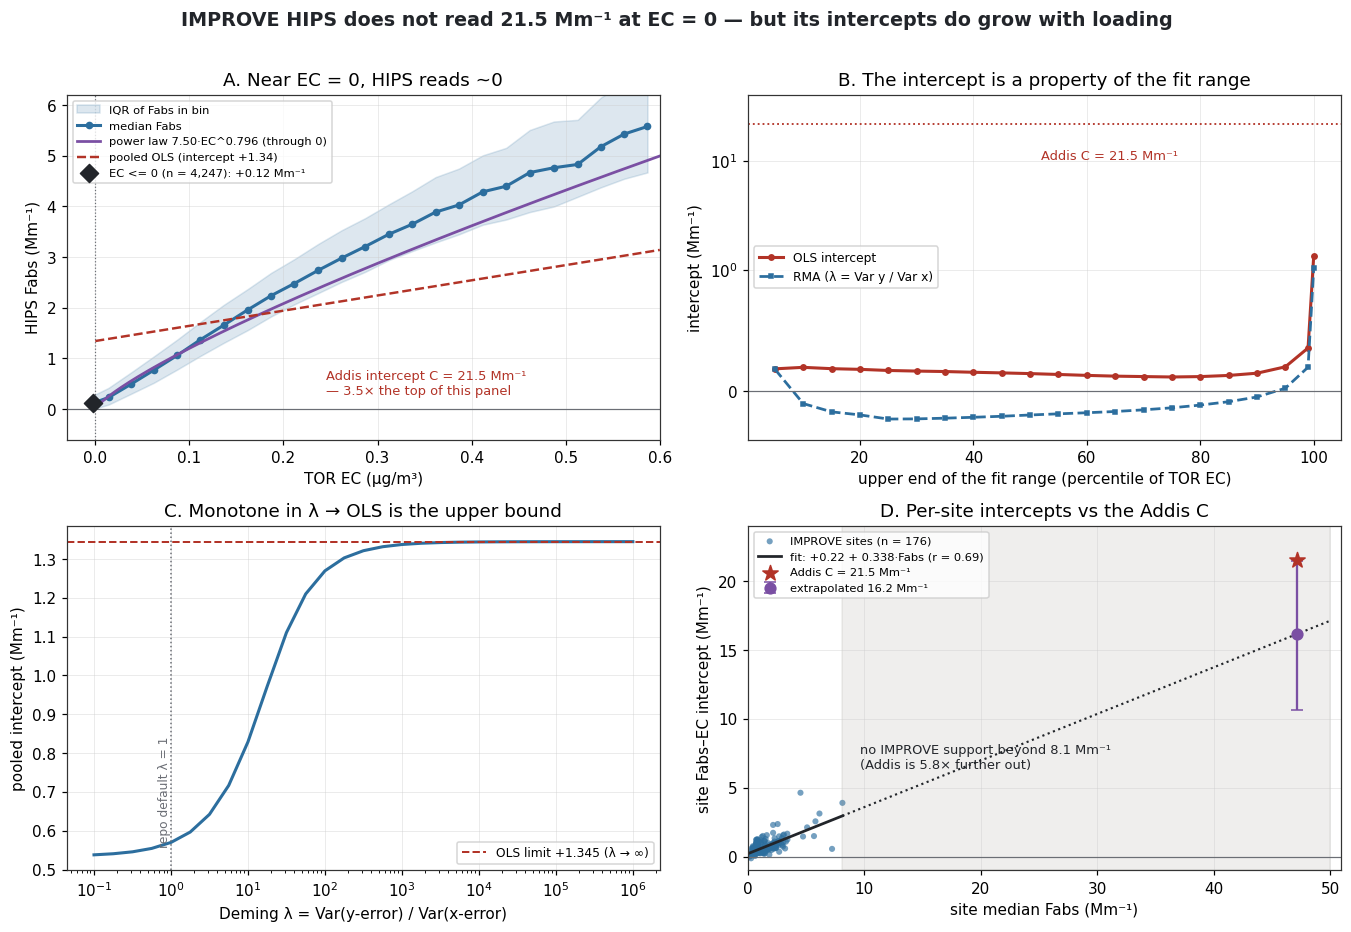

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12.4, 8.6))
ax = axes[0, 0]
edges = np.concatenate([[bridge['EC_ugm3'].min() - 1e-6, 0.0],
                        np.linspace(0.025, 0.6, 24)])
binned = bridge[bridge['EC_ugm3'] <= 0.6].copy()
binned['bin'] = pd.cut(binned['EC_ugm3'], edges)
prof = binned.groupby('bin', observed=True).agg(
    x=('EC_ugm3', 'median'), y=('Fabs', 'median'),
    lo=('Fabs', lambda v: v.quantile(.25)), hi=('Fabs', lambda v: v.quantile(.75)),
    n=('Fabs', 'size')).dropna()
ax.fill_between(prof['x'], prof['lo'], prof['hi'], color=BLUE, alpha=.16,
                label='IQR of Fabs in bin')
ax.plot(prof['x'], prof['y'], color=BLUE, lw=2, marker='o', ms=4, label='median Fabs')
grid = np.linspace(0, 0.6, 200)
ax.plot(grid, K * grid ** P, color=PURPLE, lw=1.8, ls='-',
        label=f'power law {K:.2f}·EC^{P:.3f} (through 0)')
ax.plot(grid, pooled_ols + intercepts.loc[0, 'OLS slope'] * grid, color=ACCENT, lw=1.6,
        ls='--', label=f'pooled OLS (intercept {pooled_ols:+.2f})')
ax.axhline(0, color=MUTED, lw=.8)
ax.axvline(0, color=MUTED, lw=.8, ls=':')
ax.scatter([zero_ec['EC_ugm3'].median()], [zero_ec['Fabs'].median()], s=70, zorder=5,
           color=INK, marker='D', label=f'EC <= 0 (n = {len(zero_ec):,}): '
                                        f'{zero_ec["Fabs"].median():+.2f} Mm⁻¹')
ax.annotate(f'Addis intercept C = {ADDIS_C} Mm⁻¹\n— {ADDIS_C / 6.2:.1f}× the top of this panel',
            xy=(0.245, 0.30), fontsize=8.5, color=ACCENT, ha='left')
ax.set(xlim=(-0.03, 0.6), ylim=(-0.6, 6.2), xlabel='TOR EC (µg/m³)',
       ylabel='HIPS Fabs (Mm⁻¹)', title='A. Near EC = 0, HIPS reads ~0')
ax.legend(fontsize=7.5, loc='upper left')

ax = axes[0, 1]
quantile_grid = np.concatenate([np.linspace(.05, .95, 19), [.99, 1.0]])
range_rows = []
for q in quantile_grid:
    cut = bridge['EC_ugm3'].quantile(q)
    frame = bridge[bridge['EC_ugm3'] <= cut]
    slope, intercept = ols(frame)
    _, rma_intercept, _ = rma(frame)
    range_rows.append({'q': q, 'cut': cut, 'n': len(frame), 'OLS': intercept,
                       'RMA': rma_intercept})
range_table = pd.DataFrame(range_rows)
range_table.to_csv(TABLE_DIR / 'intercept_vs_fit_range.csv', index=False)
ax.plot(range_table['q'] * 100, range_table['OLS'], color=ACCENT, lw=2, marker='o', ms=3.5,
        label='OLS intercept')
ax.plot(range_table['q'] * 100, range_table['RMA'], color=BLUE, lw=1.8, ls='--', marker='s',
        ms=3, label='RMA (λ = Var y / Var x)')
ax.axhline(0, color=MUTED, lw=.8)
ax.axhline(ADDIS_C, color=ACCENT, lw=1.2, ls=':')
ax.annotate(f'Addis C = {ADDIS_C} Mm⁻¹', xy=(52, ADDIS_C * .48), fontsize=8.5, color=ACCENT)
ax.set_yscale('symlog', linthresh=1.0)
ax.set(xlabel='upper end of the fit range (percentile of TOR EC)',
       ylabel='intercept (Mm⁻¹)', ylim=(-0.4, 40),
       title='B. The intercept is a property of the fit range')
ax.legend(fontsize=8, loc='center left')

ax = axes[1, 0]
ax.plot(sweep['lambda'], sweep['intercept'], color=BLUE, lw=2)
ax.axhline(pooled_ols, color=ACCENT, lw=1.3, ls='--',
           label=f'OLS limit {pooled_ols:+.3f} (λ → ∞)')
ax.axvline(1.0, color=MUTED, lw=1, ls=':')
ax.annotate('repo default λ = 1', xy=(1.0, sweep['intercept'].iloc[0] + 0.02), rotation=90,
            fontsize=8, color=MUTED, ha='right', va='bottom')
ax.set_xscale('log')
ax.set(xlabel='Deming λ = Var(y-error) / Var(x-error)', ylabel='pooled intercept (Mm⁻¹)',
       title='C. Monotone in λ → OLS is the upper bound')
ax.legend(fontsize=8, loc='lower right')

ax = axes[1, 1]
ax.scatter(sites['median_Fabs'], sites['intercept'], s=16, color=BLUE, alpha=.65,
           edgecolor='none', label=f'IMPROVE sites (n = {len(sites)})')
support = np.linspace(0, max_site_loading, 50)
beyond = np.linspace(max_site_loading, ADDIS_MEDIAN_FABS * 1.06, 50)
ax.plot(support, loading_fit.intercept + loading_fit.slope * support, color=INK, lw=1.8,
        label=f'fit: {loading_fit.intercept:+.2f} + {loading_fit.slope:.3f}·Fabs '
              f'(r = {loading_fit.rvalue:.2f})')
ax.plot(beyond, loading_fit.intercept + loading_fit.slope * beyond, color=INK, lw=1.4, ls=':')
ax.axvspan(max_site_loading, ADDIS_MEDIAN_FABS * 1.06, color=GREY, alpha=.14)
ax.annotate(f'no IMPROVE support beyond {max_site_loading:.1f} Mm⁻¹\n'
            f'(Addis is {ADDIS_MEDIAN_FABS / max_site_loading:.1f}× further out)',
            xy=(max_site_loading + 1.5, 6.4), fontsize=8.5, color=INK)
ax.errorbar([ADDIS_MEDIAN_FABS], [predicted],
            yerr=[[predicted - pred_ci[0]], [pred_ci[1] - predicted]], fmt='o', ms=7,
            color=PURPLE, capsize=4, label=f'extrapolated {predicted:.1f} Mm⁻¹')
ax.scatter([ADDIS_MEDIAN_FABS], [ADDIS_C], s=110, marker='*', color=ACCENT, zorder=6,
           label=f'Addis C = {ADDIS_C} Mm⁻¹')
ax.axhline(0, color=MUTED, lw=.8)
ax.set(xlabel='site median Fabs (Mm⁻¹)', ylabel='site Fabs–EC intercept (Mm⁻¹)',
       xlim=(0, ADDIS_MEDIAN_FABS * 1.08), ylim=(-1, 24),
       title='D. Per-site intercepts vs the Addis C')
ax.legend(fontsize=7.5, loc='upper left')

fig.suptitle('IMPROVE HIPS does not read 21.5 Mm⁻¹ at EC = 0 — but its intercepts do grow '
             'with loading', fontsize=12.5, fontweight='bold', color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(PLOT_DIR / 'hips_zero_four_panel.png', bbox_inches='tight', facecolor='white')
plt.show()

**Figure 2** — the two distributional statements: how big IMPROVE's own manufactured
intercepts are relative to site loading (with the Addis fraction on the same axis), and how
rare 21.5 Mm⁻¹ of *total* absorption is anywhere in IMPROVE.

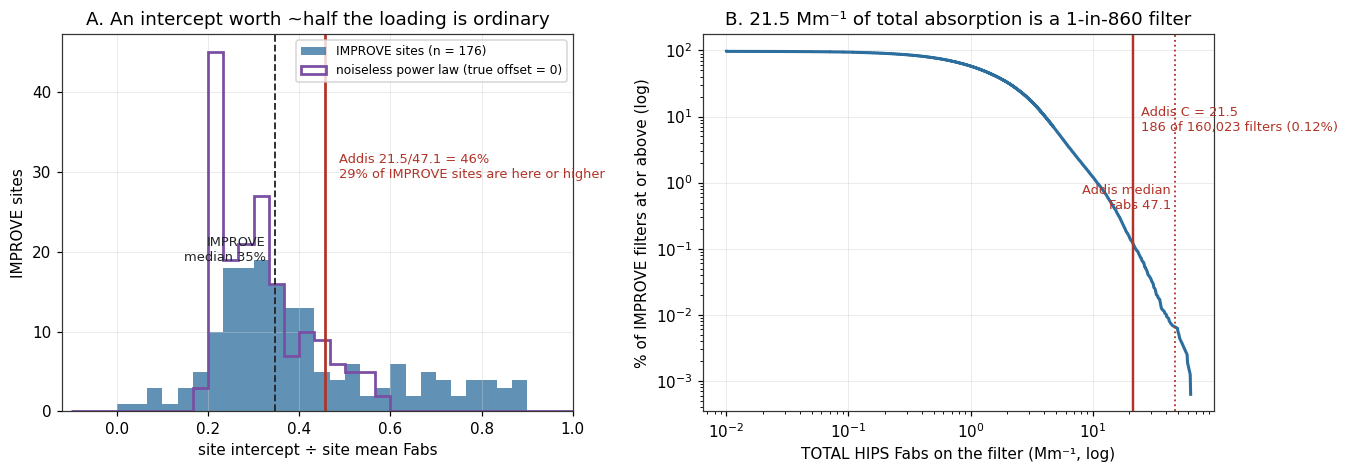

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
ax = axes[0]
bins = np.linspace(-0.1, 1.2, 40)
ax.hist(frac, bins=bins, color=BLUE, alpha=.75, label=f'IMPROVE sites (n = {len(sites)})')
ax.hist(sim_frac, bins=bins, histtype='step', lw=1.8, color=PURPLE,
        label='noiseless power law (true offset = 0)')
ax.axvline(ADDIS_FRACTION, color=ACCENT, lw=1.8)
ax.annotate(f'Addis {ADDIS_C}/{ADDIS_MEDIAN_FABS:.1f} = {100 * ADDIS_FRACTION:.0f}%\n'
            f'{100 * (frac >= ADDIS_FRACTION).mean():.0f}% of IMPROVE sites are here or higher',
            xy=(ADDIS_FRACTION + 0.03, ax.get_ylim()[1] * .62), fontsize=8.5, color=ACCENT)
ax.axvline(frac.median(), color=INK, lw=1.2, ls='--')
ax.annotate(f'IMPROVE\nmedian {100 * frac.median():.0f}%', xy=(frac.median() - 0.02,
            ax.get_ylim()[1] * .40), fontsize=8.5, color=INK, ha='right')
ax.set(xlabel='site intercept ÷ site mean Fabs', ylabel='IMPROVE sites', xlim=(-0.12, 1.0),
       title='A. An intercept worth ~half the loading is ordinary')
ax.legend(fontsize=8, loc='upper right')

ax = axes[1]
order = np.sort(bridge['Fabs'].to_numpy(float))
survival = 100 * (1 - np.arange(len(order)) / len(order))
visible = order > 0  # log x-axis; the share is still computed against all 160,023 filters
ax.plot(order[visible], survival[visible], color=BLUE, lw=2)
ax.axvline(ADDIS_C, color=ACCENT, lw=1.6)
ax.axvline(ADDIS_MEDIAN_FABS, color=ACCENT, lw=1.2, ls=':')
ax.annotate(f'Addis C = {ADDIS_C}\n{n_over_c} of {len(bridge):,} filters '
            f'({100 * n_over_c / len(bridge):.2f}%)', xy=(ADDIS_C * 1.15, 6), fontsize=8.5,
            color=ACCENT)
ax.annotate(f'Addis median\nFabs {ADDIS_MEDIAN_FABS:.1f}', xy=(ADDIS_MEDIAN_FABS * 0.93, 0.4),
            fontsize=8.5, color=ACCENT, ha='right')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set(xlabel='TOTAL HIPS Fabs on the filter (Mm⁻¹, log)',
       ylabel='% of IMPROVE filters at or above (log)',
       title=f'B. {ADDIS_C} Mm⁻¹ of total absorption is a '
             f'1-in-{round(len(bridge) / n_over_c):,} filter')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'intercept_fraction_and_scale.png', bbox_inches='tight',
            facecolor='white')
plt.show()

### What this cannot close, and why the follow-up is blocked

The intended next step is to test **curvature directly on Addis**: if the Addis Fabs–EC
relation is concave in the same way, part of C is geometry rather than offset. That test needs
an EC reference **independent of both axes** — independent of HIPS Fabs (the y-axis) and of the
FTIR calibration (the x-axis). The committed Addis data contains no such column, and the two
candidates fail for opposite reasons. Both failures are re-derived here rather than asserted.

In [16]:
from data_matching import load_filter_data  # noqa: E402  (kept local to this section)

filters = load_filter_data()
etad = filters[filters['Site'].eq('ETAD')].copy()
etad['BaseFilterId'] = etad['FilterId'].str.extract(r'^(ETAD-\d+)')
addis_hips_base = addis_hips.copy()
addis_hips_base['BaseFilterId'] = addis_hips_base['FilterId'].str.extract(r'^(ETAD-\d+)')
fabs_by_base = addis_hips_base.groupby('BaseFilterId')['Fabs'].first()


def etad_series(parameter):
    subset = etad[etad['Parameter'].eq(parameter)].dropna(subset=['Concentration'])
    return subset.groupby('BaseFilterId')['Concentration'].first()


circularity = pd.concat({'Fabs': fabs_by_base, 'ChemSpec_BC': etad_series('ChemSpec_BC_PM2.5'),
                         'ChemSpec_EC': etad_series('ChemSpec_EC_PM2.5'),
                         'EC_ftir': etad_series('EC_ftir')}, axis=1)
bc_pairs = circularity[['ChemSpec_BC', 'Fabs']].dropna()
ec_pairs = circularity[['ChemSpec_EC', 'EC_ftir']].dropna()
print(f'ChemSpec_BC vs HIPS Fabs (the x-axis): n = {len(bc_pairs)}, '
      f'r = {bc_pairs.corr().iloc[0, 1]:.4f}, median ratio '
      f'{(bc_pairs["ChemSpec_BC"] / bc_pairs["Fabs"]).median():.4f} '
      f'= Fabs / {MAC_CONVENTION:.0f} by network convention -> X-CIRCULAR')
print(f'ChemSpec_EC vs deployed FTIR EC (the y-axis): n = {len(ec_pairs)}, '
      f'r = {ec_pairs.corr().iloc[0, 1]:.4f}, median ratio '
      f'{(ec_pairs["ChemSpec_EC"] / ec_pairs["EC_ftir"]).median():.4f} '
      '-> it IS the FTIR prediction -> Y-CIRCULAR')
circularity.to_csv(TABLE_DIR / 'addis_reference_circularity.csv')
print('\nNo independent Addis EC reference exists in the committed data. Quartz TOR on '
      'co-located Addis filters is decisive precisely because it is the only measurement '
      'that is a function of neither axis (ftir_16 sizes that campaign).')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
ChemSpec_BC vs HIPS Fabs (the x-axis): n = 188, r = 0.9991, median ratio 0.1000 = Fabs / 10 by network convention -> X-CIRCULAR
ChemSpec_EC vs deployed FTIR EC (the y-axis): n = 175, r = 0.9998, median ratio 1.0000 -> it IS the FTIR prediction -> Y-CIRCULAR

No independent Addis EC reference exists in the committed data. Quartz TOR on co-located Addis filters is decisive precisely because it is the only measurement that is a function of neither axis (ftir_16 sizes that campaign).


## Takeaways

- **A generic additive HIPS zero is dead.** Every fit range, both estimators, and the
  no-fit EC ≤ 0 check put IMPROVE HIPS within ~0.2 Mm⁻¹ of zero at zero EC — under 1 % of the
  21.5 Mm⁻¹ the Addis intercept would need. The λ-monotonicity result makes that a bound
  rather than an estimate: no errors-in-variables weighting produces a larger intercept than
  OLS, so the OLS column cannot be argued upward.
- **It is dead by arithmetic as well as by fit.** 21.5 Mm⁻¹ is more absorption than 99.88 % of
  IMPROVE filters carry in *total*. An offset that size could not hide in this network.
- **But the intercept in a Fabs–EC plot is not evidence of an offset.** The relation is
  concave, and a straight line through a concave relation manufactures a positive Fabs-intercept
  (equivalently a negative x-intercept) with **no offset present at all** — demonstrated here on
  a noiseless surrogate, which reproduces 64 % of the pooled intercept and a median per-site
  intercept fraction of 30 % against the observed 35 %. Roughly one IMPROVE site in three has an
  intercept fraction at or above Addis's 46 %. Curve geometry is now a third explanation for the
  Addis intercept, alongside calibration transfer and an instrument artifact.
- **The loading-dependent artifact is NOT ruled out, and this notebook cannot rule it out.**
  Site intercepts grow with site loading (r = 0.689). The extrapolation to Addis loading lands
  at 75 % of C, which would explain nearly everything — and it is 5.8× beyond IMPROVE's support,
  so it is a hypothesis, not a measurement. What the same regression *does* settle is the
  loading-independent part: +0.221 Mm⁻¹ [+0.08, +0.37], i.e. no additive offset.
- **The follow-up that would settle it is blocked in the committed data.** Testing curvature
  directly on Addis needs an EC reference independent of both axes, and neither candidate is:
  `ChemSpec_BC` is Fabs/10 (r = 0.999 with HIPS — circular with x) and `ChemSpec_EC` is the
  deployed FTIR prediction itself (r = 0.9998 with `EC_ftir` — circular with y). This is exactly
  why co-located **quartz TOR** at Addis is decisive: it is a function of neither axis.
- **Caveats.** (1) The p = 0.796 exponent is attenuated by TOR error — binning on Fabs instead
  of EC gives p ≈ 1.08–1.10 — so treat 0.796 as an **upper bound on concavity** and therefore on
  how much of C geometry alone can explain. (2) CIs here are site-cluster bootstraps; the
  i.i.d.-row CI on the Addis-like trimmed fit ([+0.068, +0.125]) is four times narrower than the
  honest clustered one ([−0.034, +0.218]), and the clustered version is the one quoted.
  (3) The share of sites above the Addis intercept fraction moves between 29 % and 34 % with the
  per-site inclusion rule, so it is reported as a range.